# MODULE - A

### This includes the report at the end of all code blocks, also the video link

# Group - NULL VALUE A2



In [12]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

from database.bplustree import BPlusTree
import random


tree = BPlusTree()


keys = list(range(20))
random.shuffle(keys)

print("Inserted keys order:", keys)


for k in keys:
    tree.insert(k, k)


dot = tree.visualize_tree()   

dot.render('bplustree', format='png', view=True)

Inserted keys order: [18, 12, 5, 16, 13, 17, 19, 6, 11, 4, 9, 15, 1, 10, 0, 8, 7, 14, 2, 3]


'bplustree.png'

In [19]:
from database.performance import PerformanceAnalyzer

sizes = range(100, 10000, 1000)

bpt_insert, bf_insert = [], []
bpt_search, bf_search = [], []
bpt_range, bf_range = [], []
bpt_delete, bf_delete = [], []
bpt_mem, bf_mem = [], []

for n in sizes:
    pa = PerformanceAnalyzer(n, runs=10)  

    i1, i2 = pa.test_insert()
    s1, s2 = pa.test_search()
    r1, r2 = pa.test_range()
    d1, d2 = pa.test_delete()
    m1, m2 = pa.memory_usage()
    
    bpt_mem.append(m1)
    bf_mem.append(m2)

    bpt_insert.append(i1)
    bf_insert.append(i2)

    bpt_search.append(s1)
    bf_search.append(s2)

    bpt_range.append(r1)
    bf_range.append(r2)

    bpt_delete.append(d1)
    bf_delete.append(d2)

    print(f"Done for n={n}")

Done for n=100
Done for n=1100
Done for n=2100
Done for n=3100
Done for n=4100
Done for n=5100
Done for n=6100
Done for n=7100
Done for n=8100
Done for n=9100


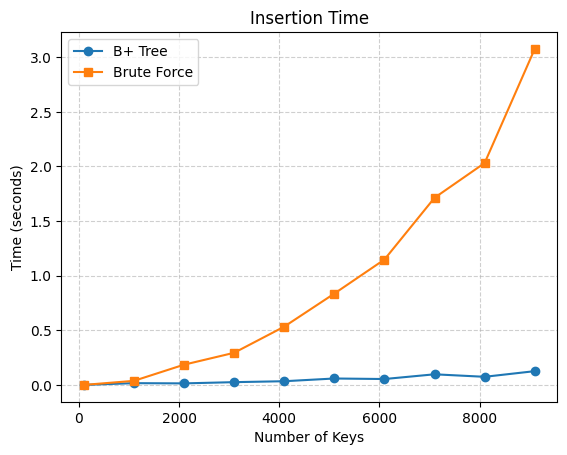

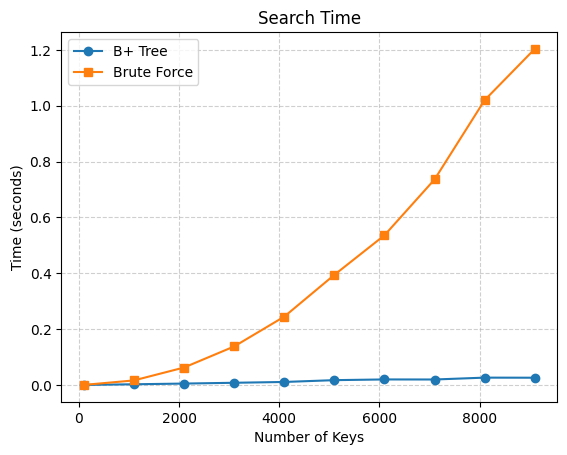

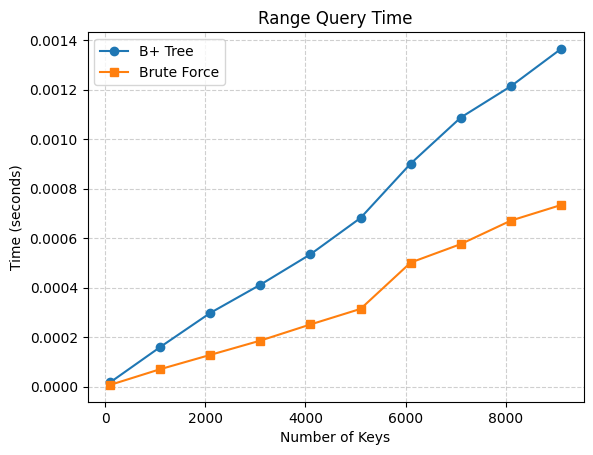

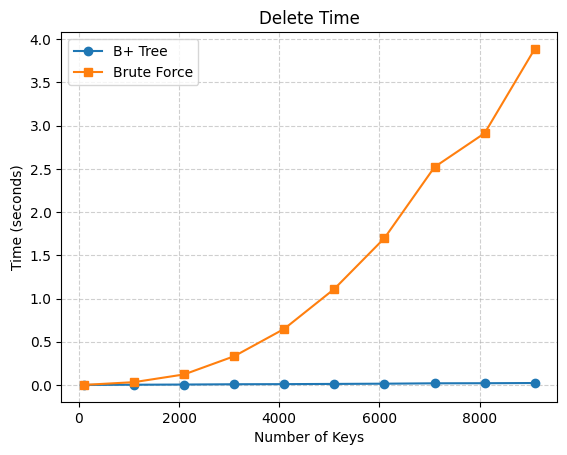

In [21]:
import matplotlib.pyplot as plt

def plot_graph(x, y1, y2, title):
    plt.figure()
    plt.plot(x, y1, marker='o', label="B+ Tree")
    plt.plot(x, y2, marker='s', label="Brute Force")

    plt.xlabel("Number of Keys")
    plt.ylabel("Time (seconds)")
    plt.title(title)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_graph(sizes, bpt_insert, bf_insert, "Insertion Time")
plot_graph(sizes, bpt_search, bf_search, "Search Time")
plot_graph(sizes, bpt_range, bf_range, "Range Query Time")
plot_graph(sizes, bpt_delete, bf_delete, "Delete Time")

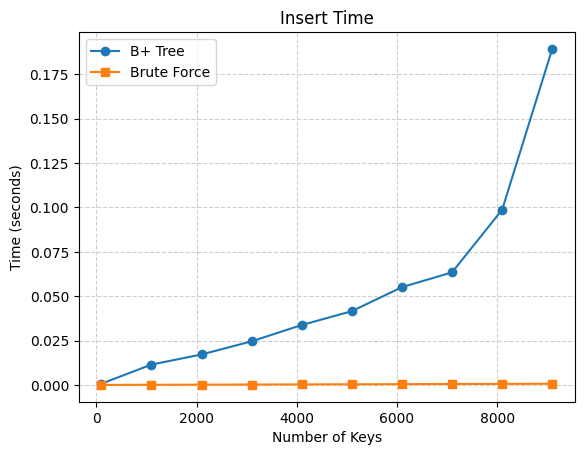

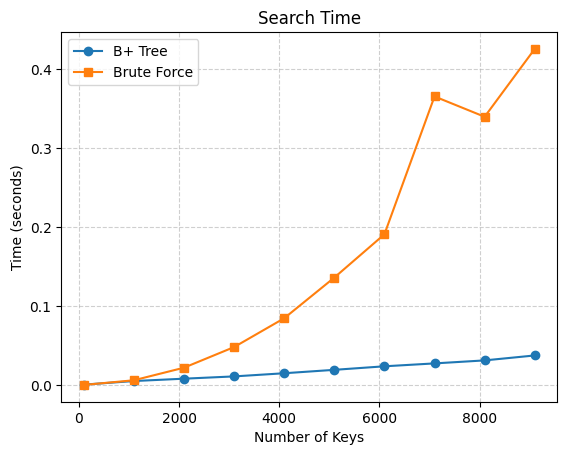

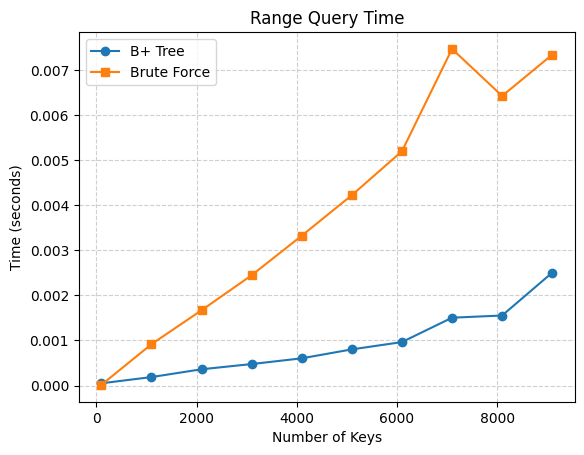

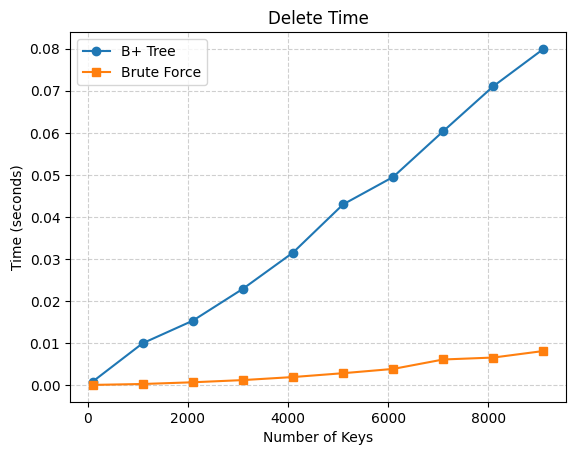

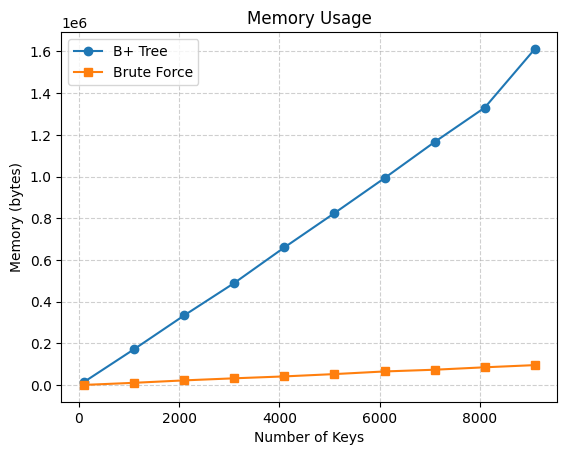

In [ ]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from database.bplustree import BPlusTree


sizes = list(range(100, 10000, 1000))

insert_bpt, insert_bf = [], []
search_bpt, search_bf = [], []
range_bpt, range_bf = [], []
delete_bpt, delete_bf = [], []
bpt_mem, bf_mem = [], []


for n in sizes:
    keys = list(range(n))
    random.shuffle(keys)


    tree = BPlusTree()

    tracemalloc.start()


    start = time.time()
    for k in keys:
        tree.insert(k, k)
    insert_bpt.append(time.time() - start)


    start = time.time()
    for k in keys:
        tree.search(k)
    search_bpt.append(time.time() - start)


    start = time.time()
    tree.range_query(n//4, n//2)
    range_bpt.append(time.time() - start)


    start = time.time()
    for k in keys:
        tree.delete(k)
    delete_bpt.append(time.time() - start)

    current, peak = tracemalloc.get_traced_memory()
    bpt_mem.append(peak)

    tracemalloc.stop()


    arr = []

    tracemalloc.start()

    # Insert
    start = time.time()
    for k in keys:
        arr.append(k)
    insert_bf.append(time.time() - start)

    # Search
    start = time.time()
    for k in keys:
        k in arr
    search_bf.append(time.time() - start)

    # Range Query
    start = time.time()
    [x for x in arr if n//4 <= x <= n//2]
    range_bf.append(time.time() - start)

    # Delete
    start = time.time()
    for k in keys:
        if k in arr:
            arr.remove(k)
    delete_bf.append(time.time() - start)

    current, peak = tracemalloc.get_traced_memory()
    bf_mem.append(peak)

    tracemalloc.stop()



def plot_graph(x, y1, y2, title, ylabel):
    plt.figure()
    plt.plot(x, y1, marker='o', label="B+ Tree")
    plt.plot(x, y2, marker='s', label="Brute Force")
    plt.xlabel("Number of Keys")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_graph(sizes, insert_bpt, insert_bf, "Insert Time", "Time (seconds)")
plot_graph(sizes, search_bpt, search_bf, "Search Time", "Time (seconds)")
plot_graph(sizes, range_bpt, range_bf, "Range Query Time", "Time (seconds)")
plot_graph(sizes, delete_bpt, delete_bf, "Delete Time", "Time (seconds)")
plot_graph(sizes, bpt_mem, bf_mem, "Memory Usage", "Memory (bytes)")

In [24]:
import pandas as pd

df = pd.DataFrame({
    "n": list(sizes),
    "Insert_BPT": bpt_insert,
    "Insert_BF": bf_insert,
    "Search_BPT": bpt_search,
    "Search_BF": bf_search,
    "Range_BPT": bpt_range,
    "Range_BF": bf_range,
    "Delete_BPT": bpt_delete,
    "Delete_BF": bf_delete,
    "Memory_BPT": bpt_mem,
    "Memory_BF": bf_mem
})

df

,n,Insert_BPT,Insert_BF,Search_BPT,Search_BF,Range_BPT,Range_BF,Delete_BPT,Delete_BF,Memory_BPT,Memory_BF
0,100,0.000473,0.000372,0.000160,0.000153,0.000017,0.000007,0.000161,0.000263,15328,1368
1,1100,0.016475,0.037644,0.002473,0.016281,0.000160,0.000071,0.002404,0.032154,172456,11476
2,2100,0.014446,0.185567,0.004983,0.062454,0.000298,0.000128,0.004532,0.121424,334512,23124
3,3100,0.025694,0.294461,0.007846,0.137881,0.000412,0.000186,0.007949,0.331915,489944,33076
4,4100,0.034213,0.533789,0.010739,0.244593,0.000535,0.000251,0.009284,0.648810,660512,42180
5,5100,0.059172,0.836331,0.017230,0.394259,0.000682,0.000314,0.011742,1.111082,825056,53316
6,6100,0.054304,1.148121,0.019788,0.535960,0.000901,0.000501,0.014409,1.698557,992904,65956
7,7100,0.097564,1.713247,0.019565,0.735897,0.001087,0.000576,0.018884,2.521396,1166064,74244
8,8100,0.074676,2.031575,0.026260,1.019963,0.001213,0.000671,0.019785,2.912940,1330736,85860
9,9100,0.126371,3.075867,0.025955,1.203527,0.001364,0.000734,0.022199,3.888222,1612208,96356


## Video Demonstration

[Click here to watch the Module A demonstration](https://drive.google.com/file/d/1nvNY14adI79_OiciEwb0BKM8dLDXPRcJ/view?usp=sharing)